In [1]:
import tensorflow as tf

In [2]:
model = tf.keras.models.load_model('brain_tumor_model.keras')

In [3]:
last_conv_layer_name = "conv5_block3_out"

In [4]:
import tensorflow as tf
import numpy as np
import cv2

def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

In [5]:
def preprocess_image(img_path, size=(224,224)):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=size)
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = img / 255.0
    return np.expand_dims(img, axis=0)

In [6]:
import matplotlib.pyplot as plt

def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * alpha + img

    plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

c:\MyProjects\mri_project\venv\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_1']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
[[0.0024811  0.04210132 0.01237585 0.94304174]]


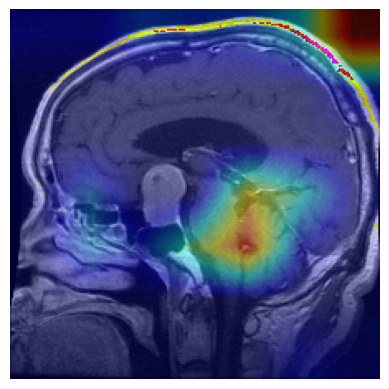

In [7]:
img_path = "Tr-pi_1396.jpg"

img_array = preprocess_image(img_path)

heatmap = get_gradcam_heatmap(
    model,
    img_array,
    last_conv_layer_name
)

print(model.predict(img_array))

display_gradcam(img_path, heatmap)